In [ ]:
%%capture
# Installs Unsloth, Xformers (Flash Attention) and all other packages!
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
!pip install neptune --quiet

In [ ]:
### Lora and model downloading parameters

lora_parameters = {
    'lora_r' : 16,
    'target_modules' : ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj",],
    'lora_alpha' : 16,
    'lora_dropout' : 0, # available also another implementations, but 0 is optimized in unsloth
    'lora_bias' : "none",
    'lora_use_gradient_checkpointing' : "unsloth",
    'lora_random_state' : 3407,
    'lora_use_rslora' : False,
    'lora_loftq_config' : None
}
model_parameters = {
    'model_name' : 'unsloth/llama-3-8b-bnb-4bit',
    'model_max_seq_length' : 1200,
    'model_dtype' : None ,
    'model_load_in_4bit' : True
}


In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_parameters['model_name'],
    max_seq_length = model_parameters['model_max_seq_length'],
    dtype = model_parameters['model_dtype'],
    load_in_4bit = model_parameters['model_load_in_4bit'],
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_parameters['lora_r'],
    target_modules = lora_parameters['target_modules'],
    lora_alpha = lora_parameters['lora_alpha'],
    lora_dropout = lora_parameters['lora_dropout'],
    bias = lora_parameters['lora_bias'],
    use_gradient_checkpointing = lora_parameters['lora_use_gradient_checkpointing'],
    random_state = lora_parameters['lora_random_state'],
    use_rslora = lora_parameters['lora_use_rslora'],  # We support rank stabilized LoRA
    loftq_config = lora_parameters['lora_loftq_config'], # And LoftQ
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

==((====))==  Unsloth: Fast Llama patching release 2024.7
   \\   /|    GPU: Tesla T4. Max memory: 14.748 GB. Platform = Linux.
O^O/ \_/ \    Pytorch: 2.3.1+cu121. CUDA = 7.5. CUDA Toolkit = 12.1.
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.26.post1. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/172 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

Unsloth 2024.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [ ]:
prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.
Instruction:
You are given 2 questions and you need to compare them and understand are they semantically similar or not, by providing explanation and after that label. 0 means dissimilar and 1 means similar.
Question 1: {{question_1}}
Question 2: {{question_2}}
Explanation: {{expandlab}}
""" #explanation: exp + label: lbl

In [ ]:
from datasets import load_dataset
dataset = load_dataset('borismartirosyan/glue-qqp-sampled-explanation')

EOS_TOKEN = tokenizer.eos_token
def formatting_prompts_func(examples):
    question_1 = examples["question1"]
    question_2 = examples["question2"]
    explanations = examples["explanation"]
    labels = examples["label"]
    texts = []
    for q1, q2, exp, labl in zip(question_1, question_2, explanations, labels):
        # Must add EOS_TOKEN, otherwise your generation will go on forever! BOS token will be added automatically
        text = prompt.replace('{{question_1}}', q1).replace('{{question_2}}', q2).replace("{{expandlab}}", exp+' label: ' + labl) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }


dataset = dataset.map(formatting_prompts_func, batched = True)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
for dp in dataset['train']['text'][:5]:
  print('='*100)
  print(dp)

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.
Instruction:
You are given 2 questions and you need to compare them and understand are they semantically similar or not, by providing explanation and after that label. 0 means dissimilar and 1 means similar.
Question 1: How much noise does one bar of the iPhone volume slider make in decibels?
Question 2: What are some social impacts of The Agricultural Revolution and what are some examples?
Explanation: The questions 'How much noise does one bar of the iPhone volume slider make in decibels?' and 'What are some social impacts of The Agricultural Revolution and what are some examples?' are considered dissimilar because they address different topics, concepts, or inquiries. label: 0 
<|end_of_text|>
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately c

In [ ]:
import os
os.environ["NEPTUNE_PROJECT"] = "Project Name"
os.environ["NEPTUNE_API_TOKEN"] = "API KEY"

In [ ]:
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
import neptune

run = neptune.init_run()

#class UpdatedSFTTrainer(SFTTrainer):
    # def compute_loss(self, model, inputs, return_outputs=False):
    #     outputs = model(**inputs)
    #     loss = outputs.loss
    #     # Log training loss to Neptune
    #     run["train/loss"].log(loss.item())
    #     return (loss, outputs) if return_outputs else loss

training_arguments = {
    'evaluation_strategy' : "steps",
    'logging_strategy' : "steps",
    'save_strategy' : "epoch",
    'eval_steps' : 10,
    'per_device_train_batch_size' : 2,
    'evaluation_strategy' : "steps",
    'logging_strategy' : "steps",
    'save_strategy' : "epoch",
    'eval_steps' : 10,
    'per_device_train_batch_size' : 2,
    'gradient_accumulation_steps' : 4,
    'warmup_steps' : 5,
    'learning_rate' : 2e-4,
    'fp16' : not is_bfloat16_supported(),
    'bf16' : is_bfloat16_supported(),
    'logging_steps' : 1,
    'optim' : "adamw_8bit",
    'weight_decay' : 0.01,
    'lr_scheduler_type' : "cosine",
    'seed' : 3407,
    'output_dir' : "outputs",
    'num_train_epochs' : 2
}
params = {**lora_parameters, **model_parameters, **training_arguments}
run["parameters"] = params

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,  # Pass the entire dataset instead of dataset['texts']
    dataset_text_field = "text",
    max_seq_length = 100,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        evaluation_strategy=training_arguments['evaluation_strategy'],
        logging_strategy=training_arguments['logging_strategy'],
        save_strategy=training_arguments['save_strategy'],
        eval_steps=training_arguments['eval_steps'],
        per_device_train_batch_size = training_arguments['per_device_train_batch_size'],
        gradient_accumulation_steps = training_arguments['gradient_accumulation_steps'],
        warmup_steps = training_arguments['warmup_steps'],
        learning_rate = training_arguments['learning_rate'],
        fp16 = training_arguments['fp16'],
        bf16 = training_arguments['bf16'],
        logging_steps = training_arguments['logging_steps'],
        optim = training_arguments['optim'],
        weight_decay = training_arguments['weight_decay'],
        lr_scheduler_type = training_arguments['lr_scheduler_type'],
        seed = training_arguments['seed'],
        output_dir = training_arguments['output_dir'],
        num_train_epochs=training_arguments['num_train_epochs']
    ),
)

trainer.model.print_trainable_parameters()
trainer.train()

ModuleNotFoundError: No module named 'trl'

In [ ]:
from tqdm import tqdm

# Inference acceleration
FastLanguageModel.for_inference(trainer.model)

predicted_classes = list()
trainer.model.to('cuda')
for dp in tqdm(trainer.eval_dataset):

    dp = tokenizer.decode(dp['input_ids'])

    dp = tokenizer(dp, add_special_tokens=False, return_tensors='pt')['input_ids'][0].to('cuda')

    dp = dp

    outputs = model.generate(dp, max_new_tokens = 400, use_cache = True)

    possible_label = tokenizer.decode(outputs[0]).split('label:')[-1].replace('<|end_of_text|>', '').replace('<|begin_of_text|>', '').replace('\n', '').replace('://', '').strip()
    if len(possible_label) == 1:

      predicted_classes.append(possible_label)
    else:
      predicted_classes.append(tokenizer.decode(outputs[0]))



  0%|          | 0/200 [00:00<?, ?it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  0%|          | 1/200 [00:37<2:03:38, 37.28s/it]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  1%|          | 2/200 [00:37<51:52, 15.72s/it]  The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
  2%|▏         | 3/200 [00:38<29:02,  8.84s/it]The attention mask and the pad token id were not set. As a c

In [ ]:
y_pred = predicted_classes

In [ ]:
import neptune.integrations.sklearn as npt_utils

run["cls_summary"] = npt_utils.create_classifier_summary(gbc, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       101
           1       0.99      1.00      0.99        99

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



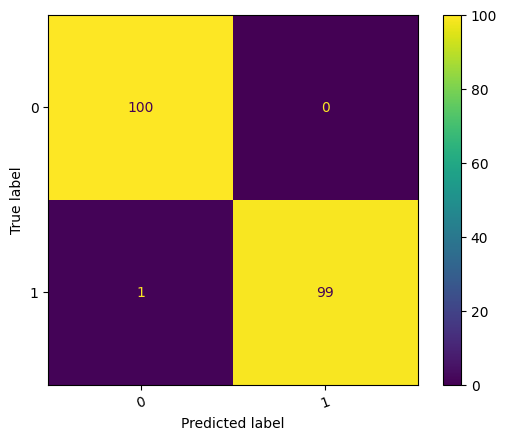

In [ ]:
y_true = [x['text'].split("label:")[-1].replace('\n<|end_of_text|>', '').strip() for x in dataset['validation']]

import pandas as pd
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
#print(classification_report(y_true, y_pred))

df = pd.DataFrame([y_pred, y_true]).T.dropna().reset_index(drop=True)
print(classification_report(df[0], df[1]))
print('='*100)
print(ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation=20))

In [ ]:
fig = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation=20)
run['confusion_matrix'] = fig